In [ ]:
import pandas as pd

df = pd.read_csv('/content/air_quality_master.csv')
display(df.head())

,city,pollutant,date_local,avg_concentration
0,Chicago,CO,2015-01-01,0.166613
1,Chicago,CO,2015-01-02,0.301167
2,Chicago,CO,2015-01-03,0.460375
3,Chicago,CO,2015-01-04,0.241875
4,Chicago,CO,2015-01-05,0.201375


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66237 entries, 0 to 66236
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   city               66237 non-null  object 
 1   pollutant          66237 non-null  object 
 2   date_local         66237 non-null  object 
 3   avg_concentration  66237 non-null  float64
dtypes: float64(1), object(3)
memory usage: 2.0+ MB


### Pollutant Trends Over Time per City

The following plots visualize the average concentration of each pollutant (`CO`, `NO2`, `O3`, `SO2`, `PM10`, `PM2.5`) for each city over the period 2015-2024. Each plot shows the daily average concentration for a specific city and pollutant combination.

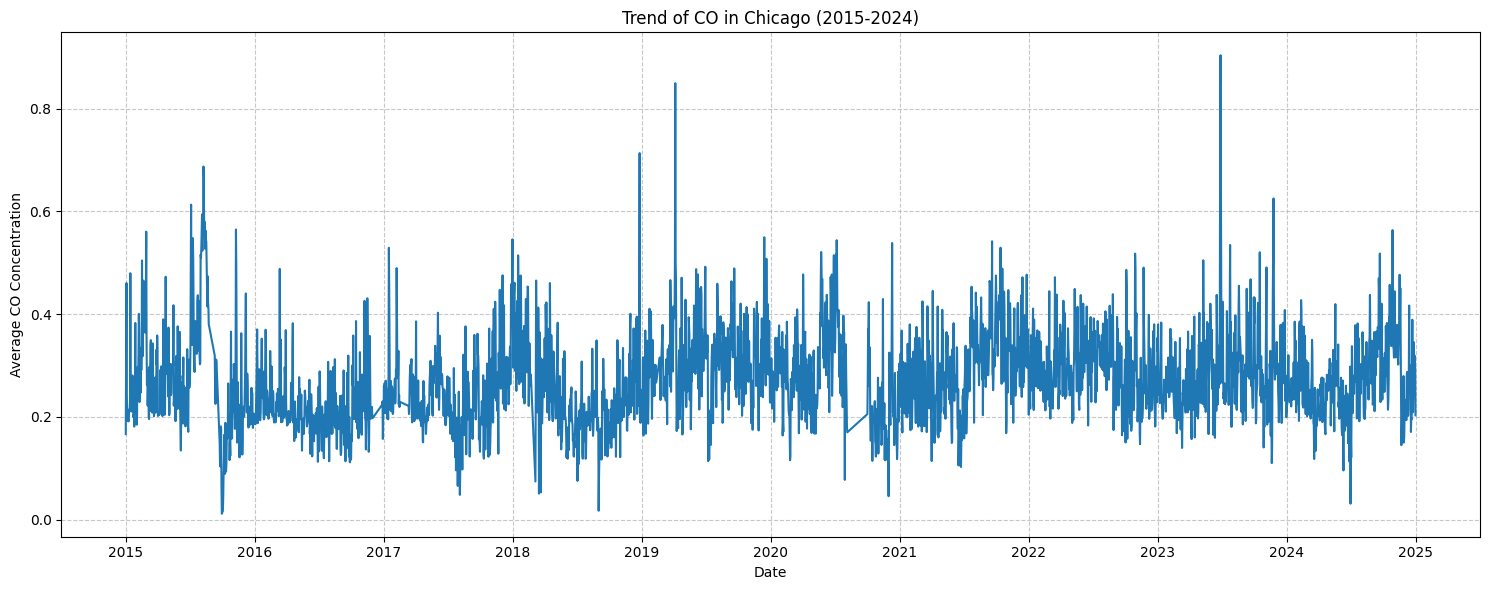

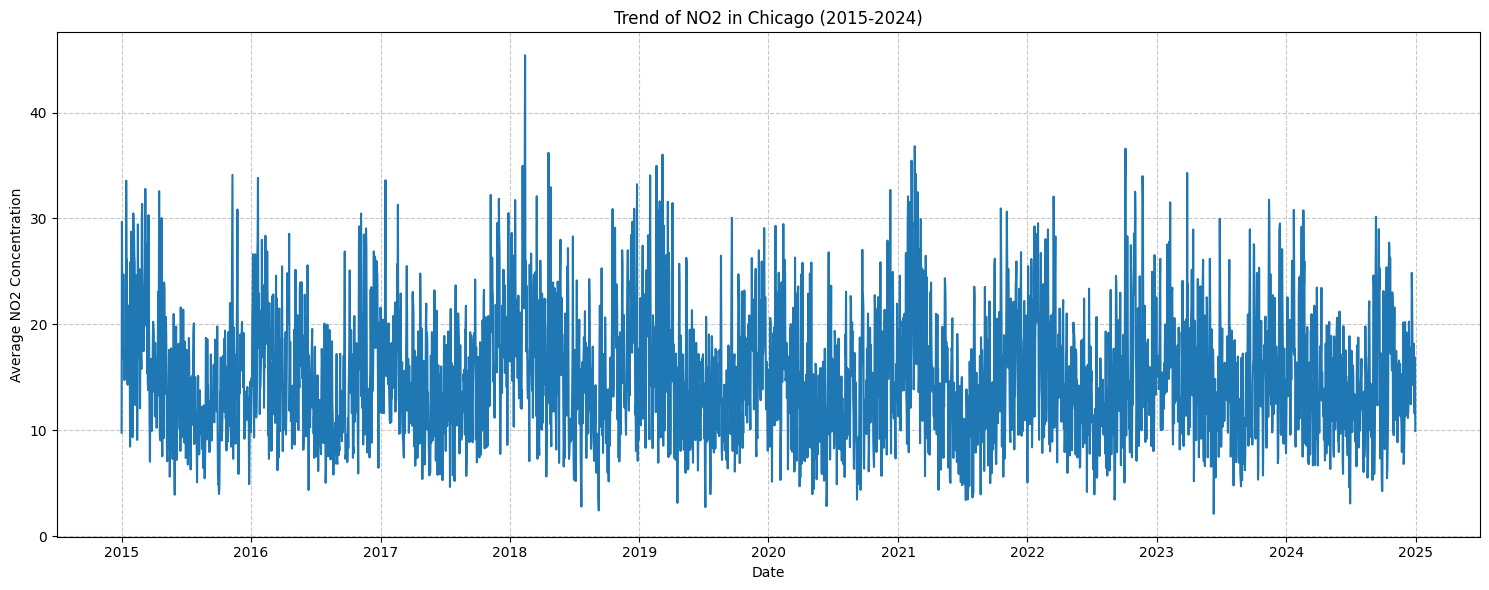

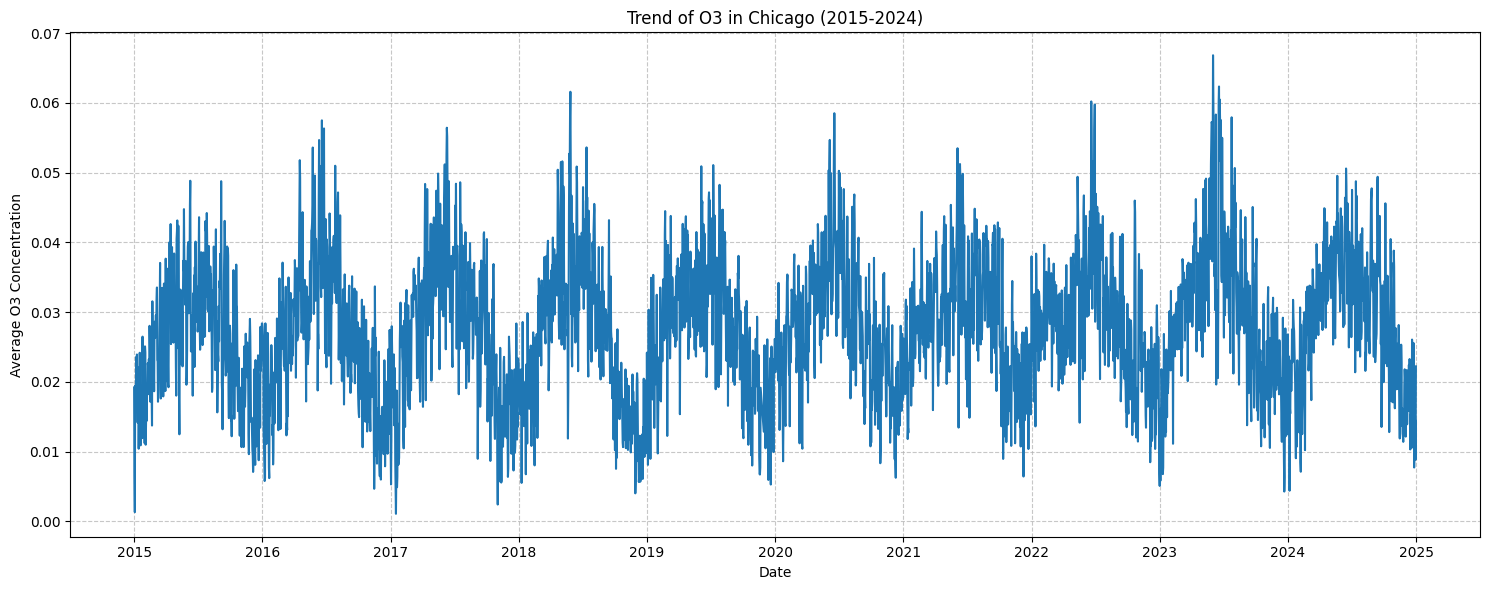

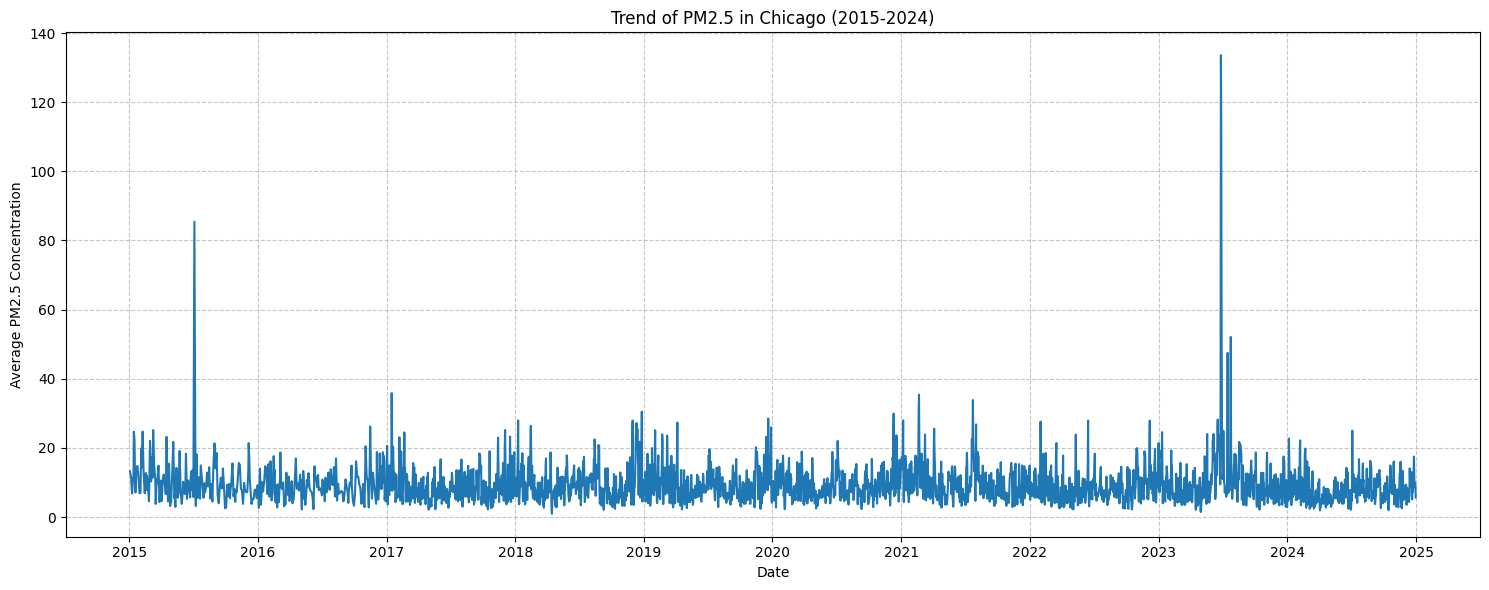

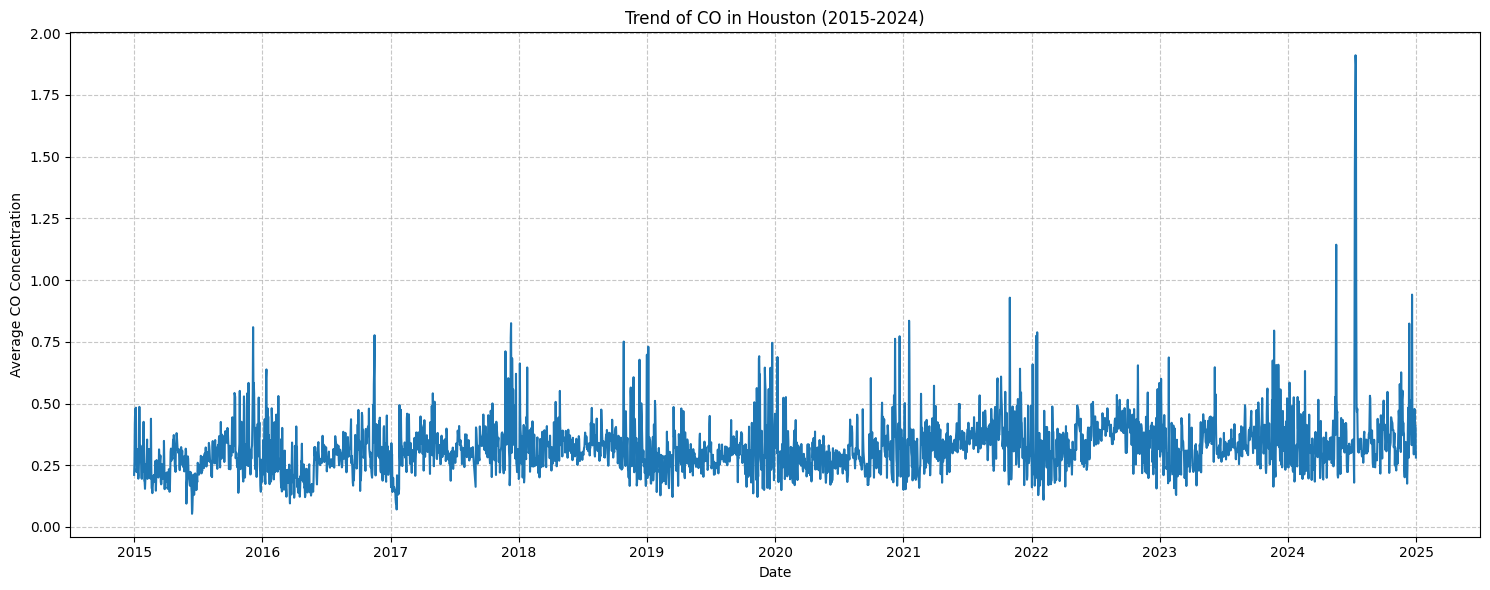

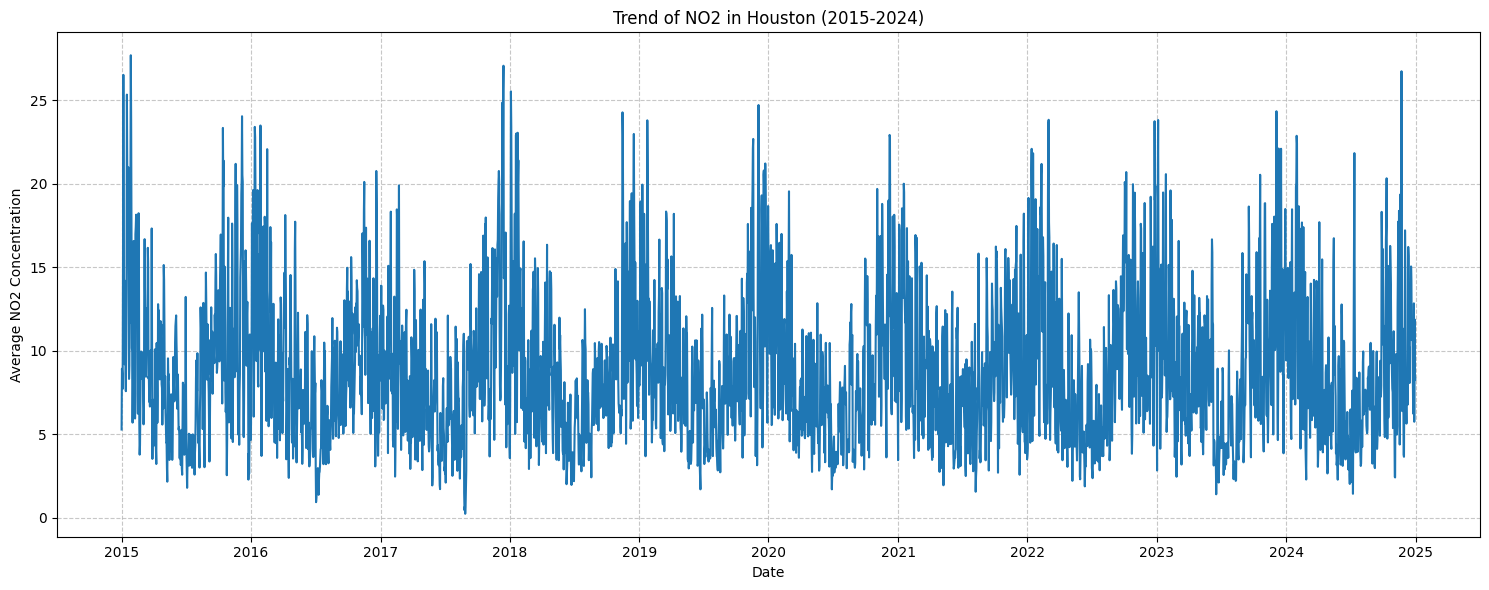

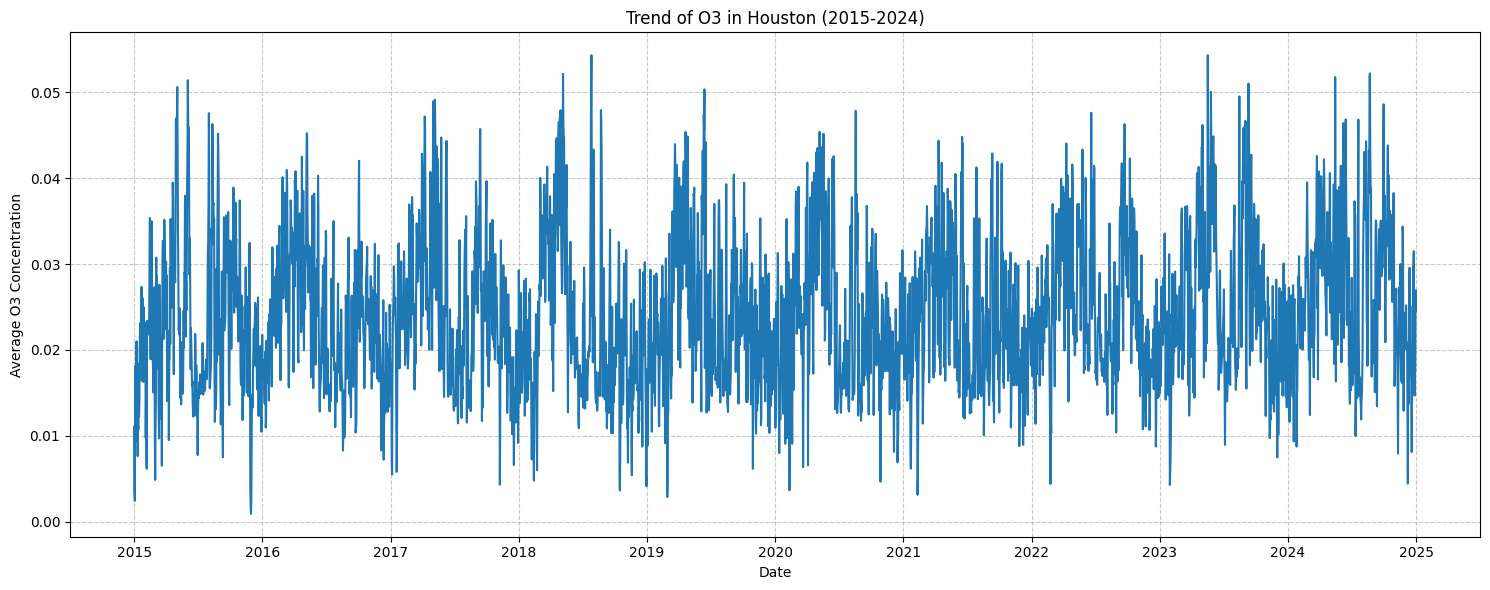

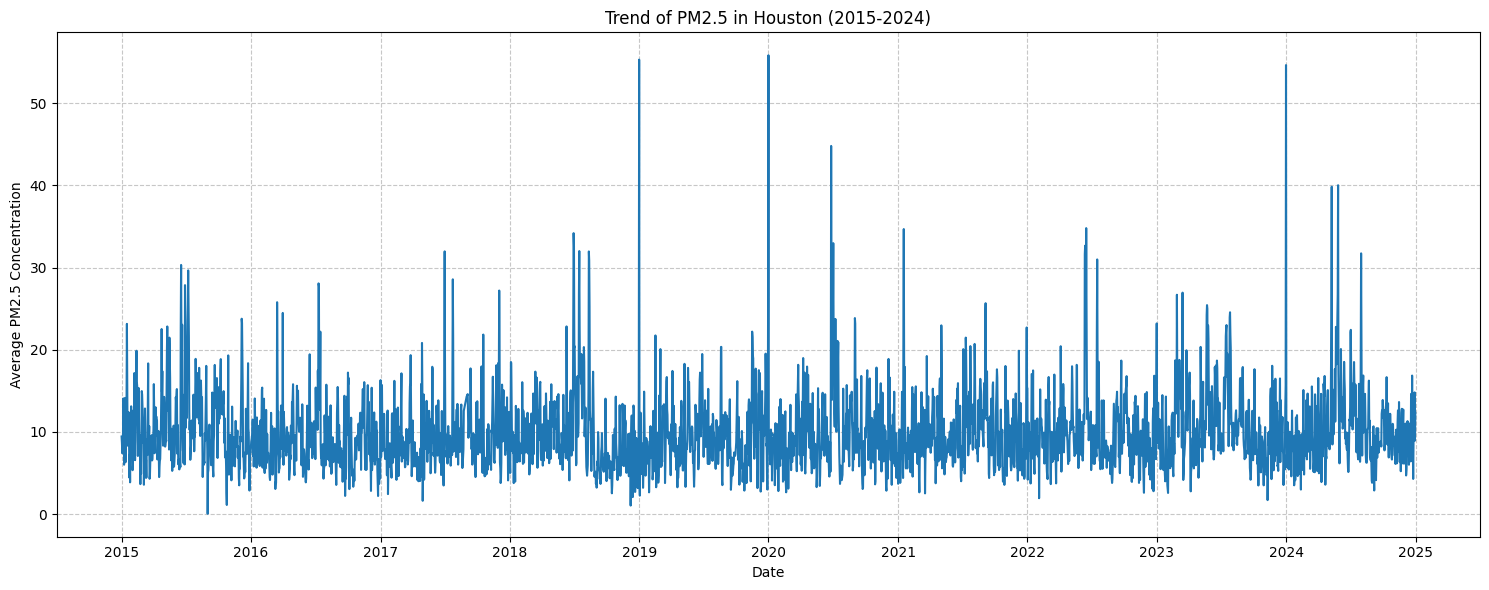

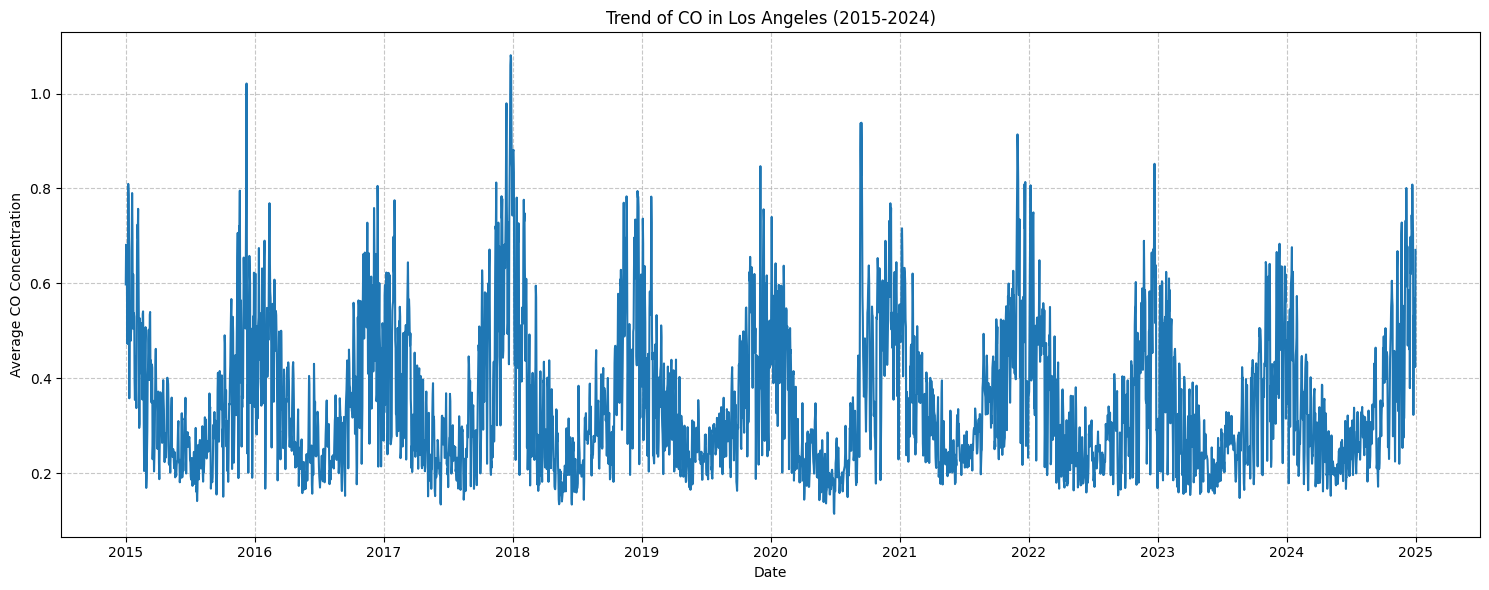

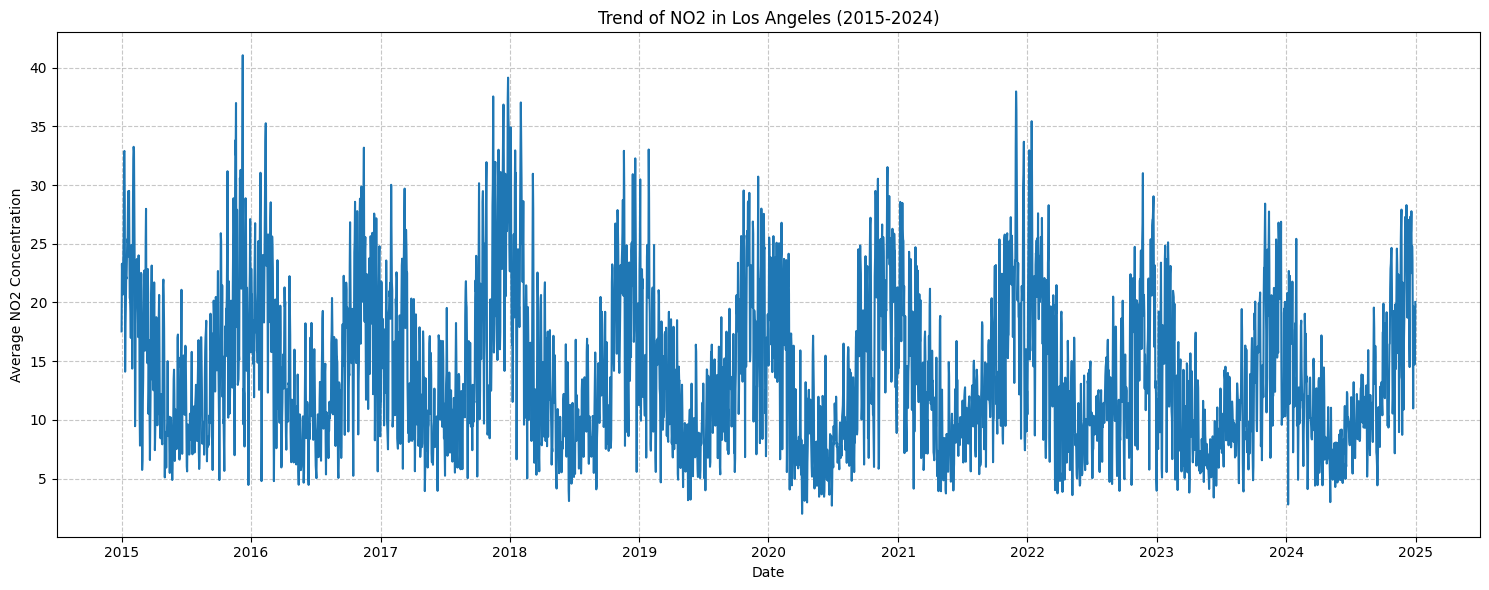

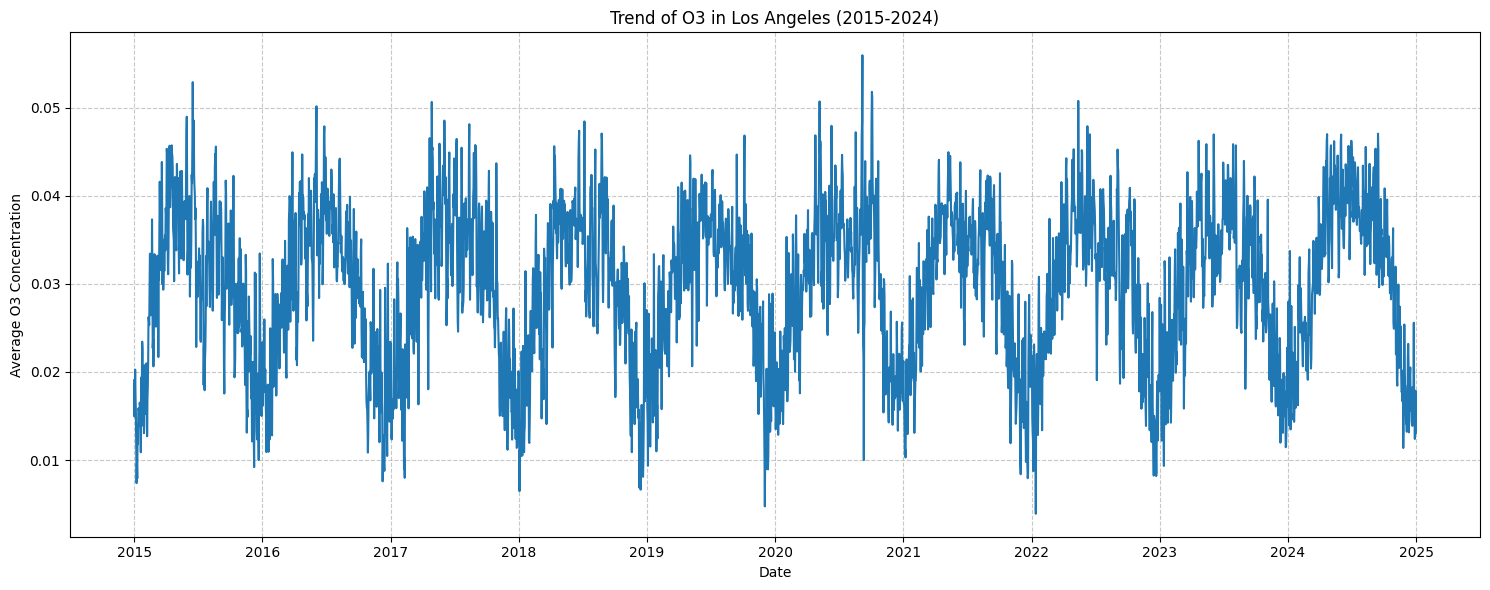

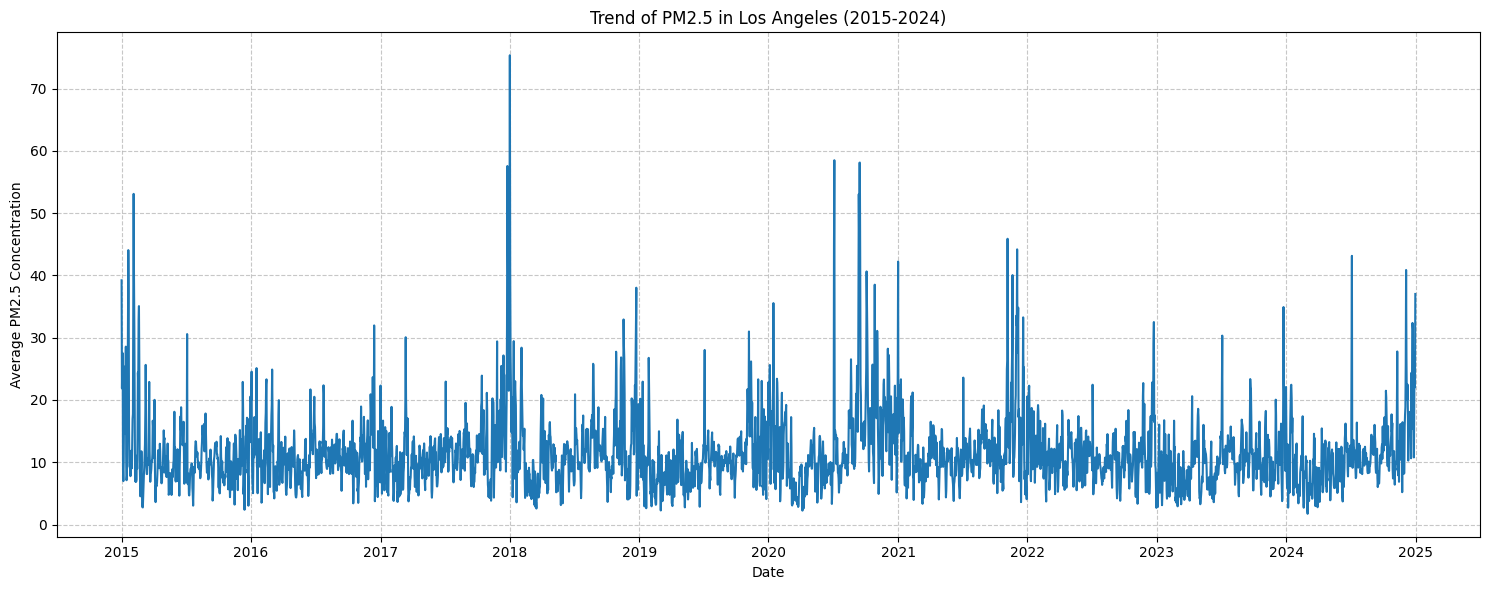

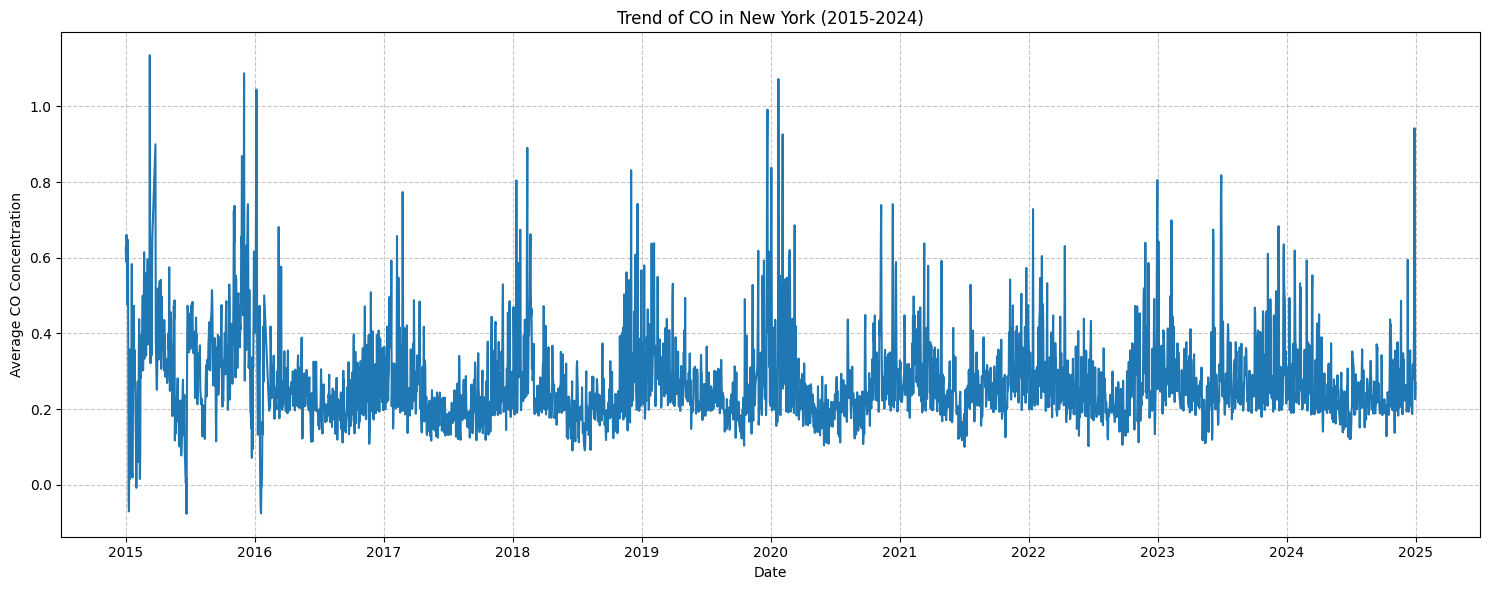

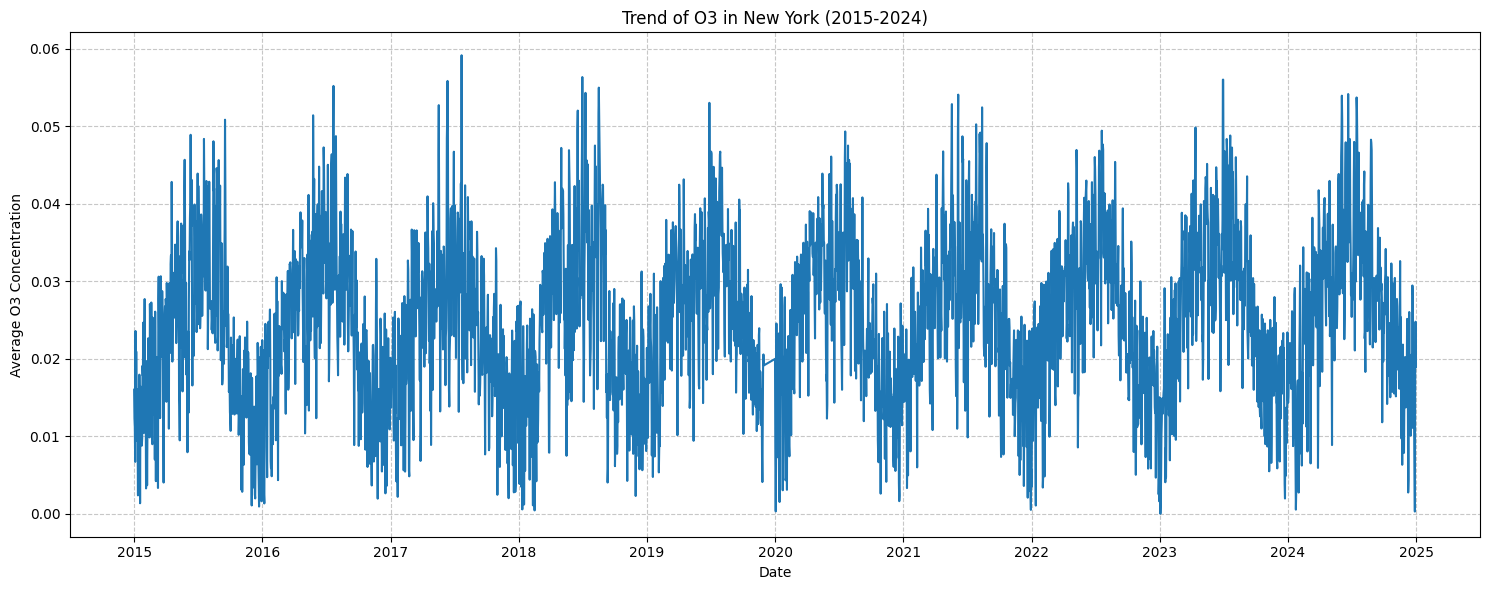

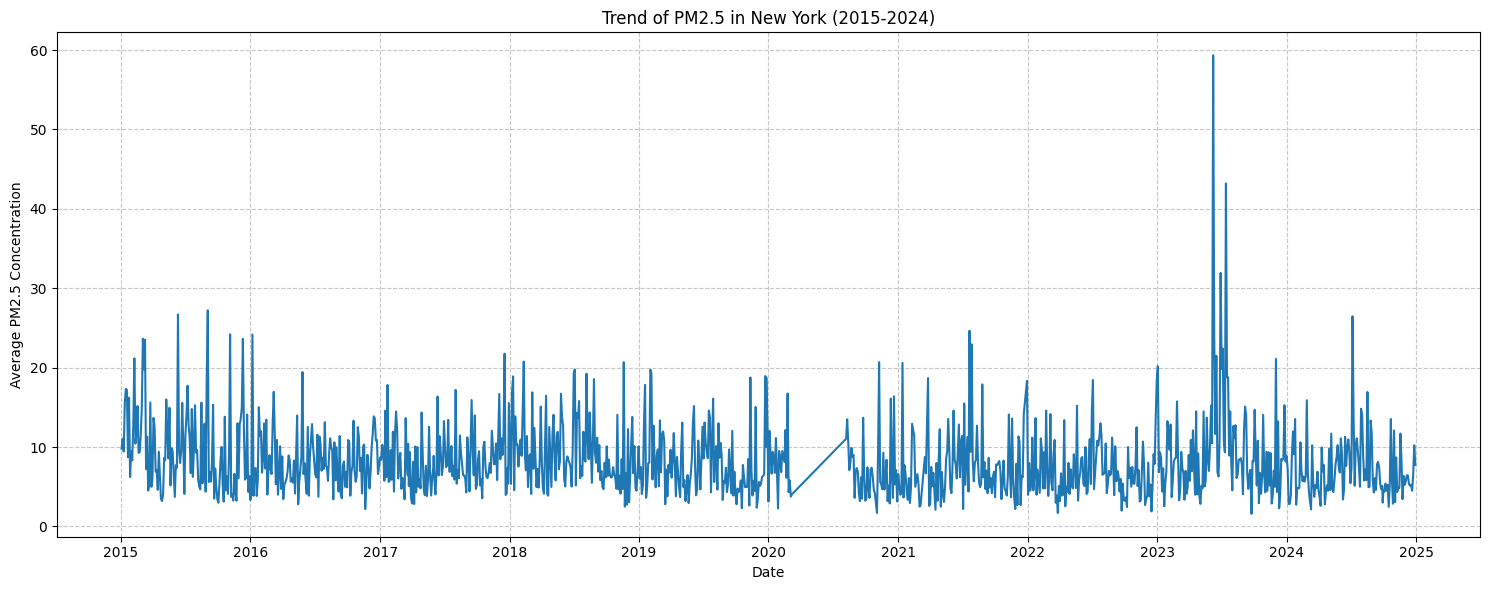

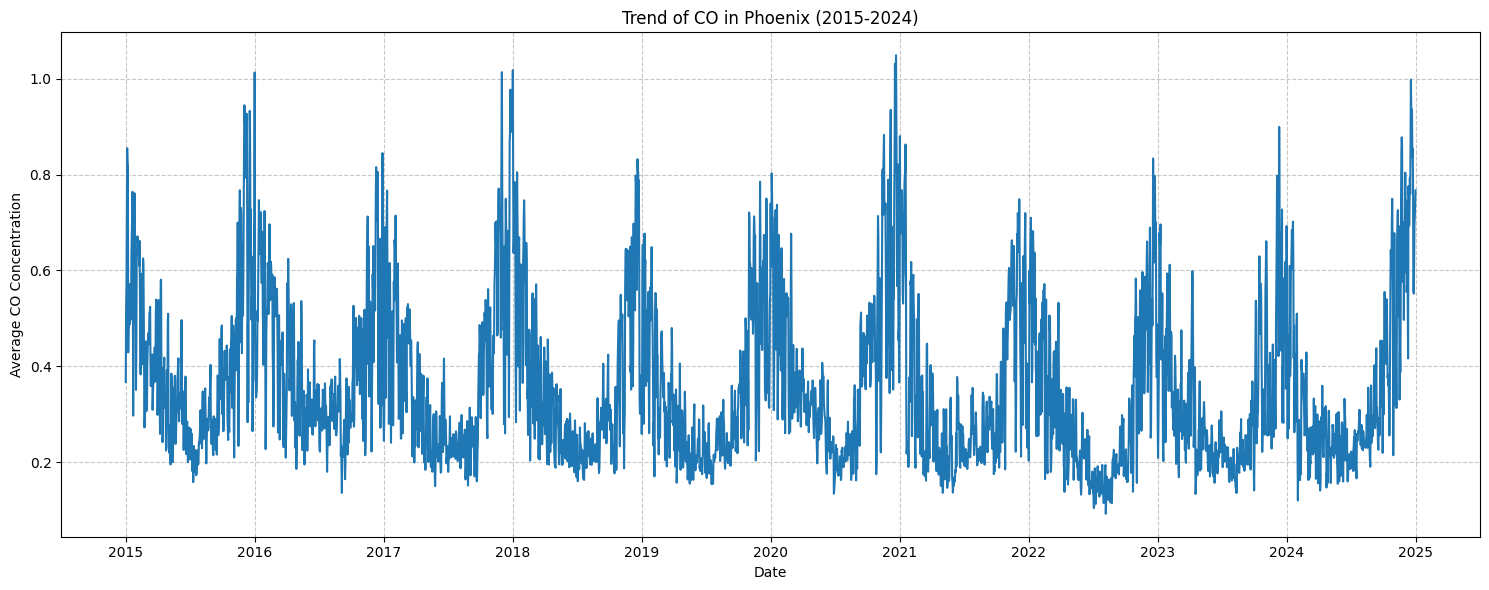

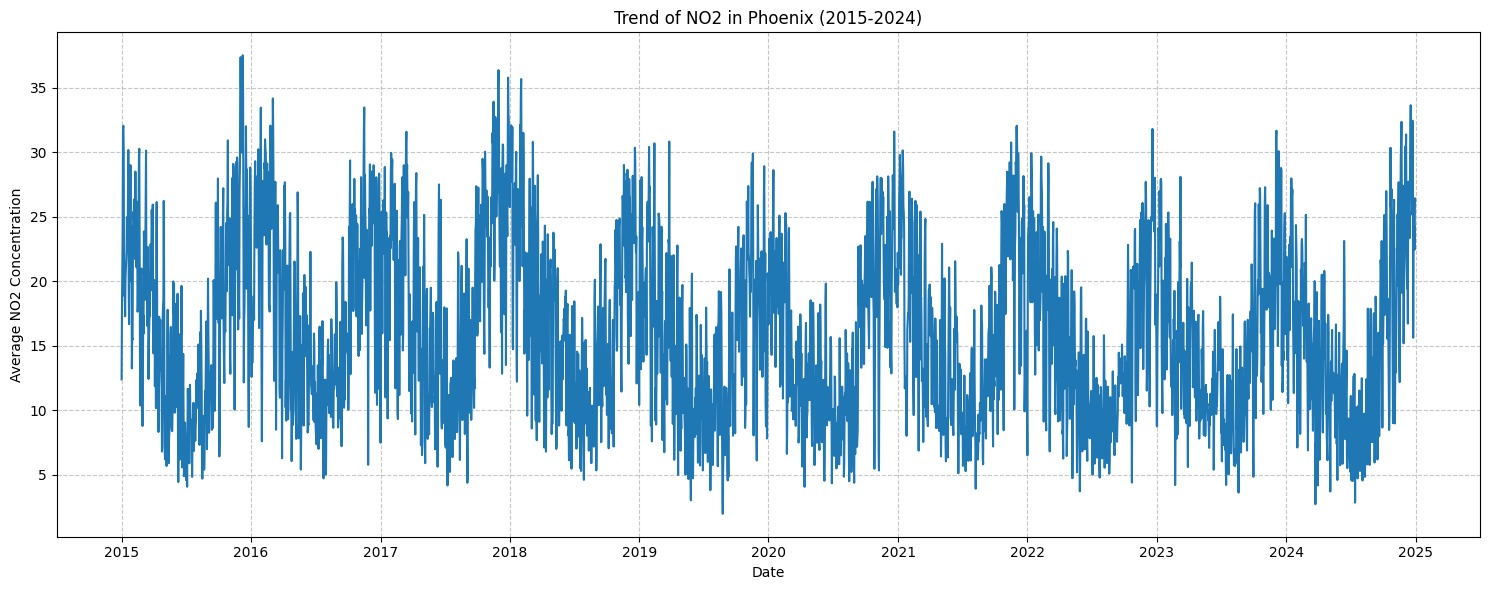

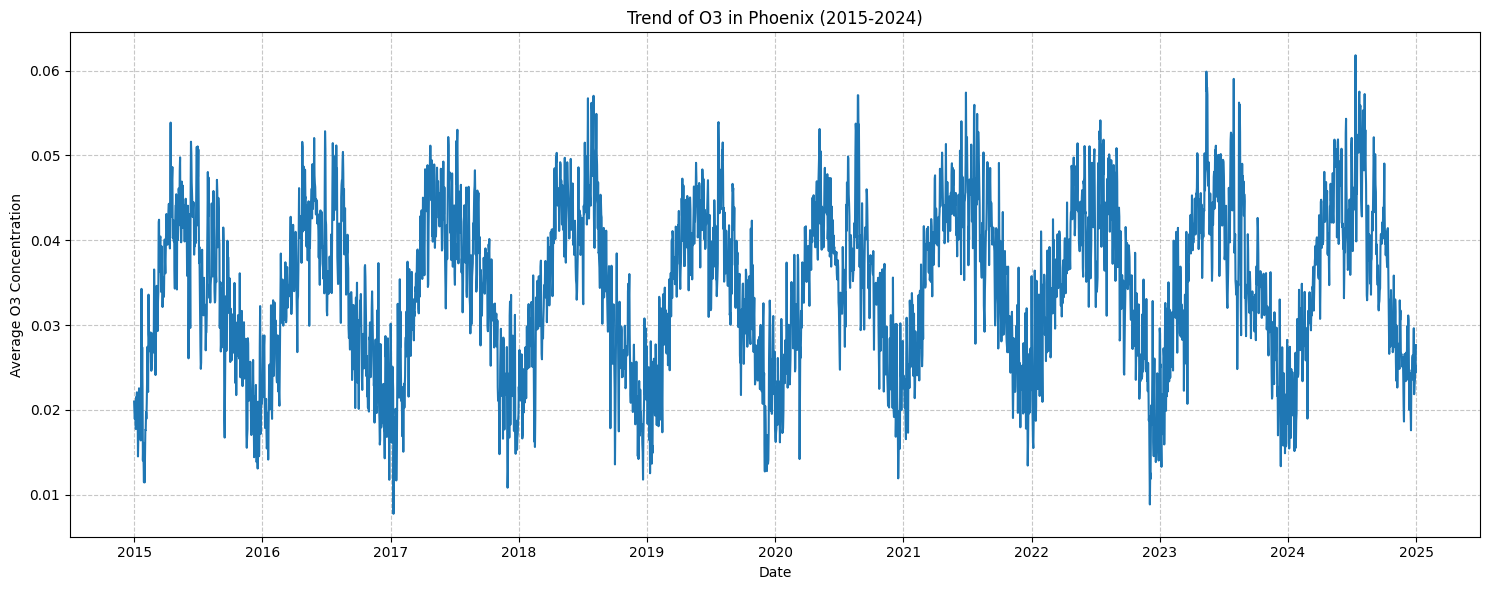

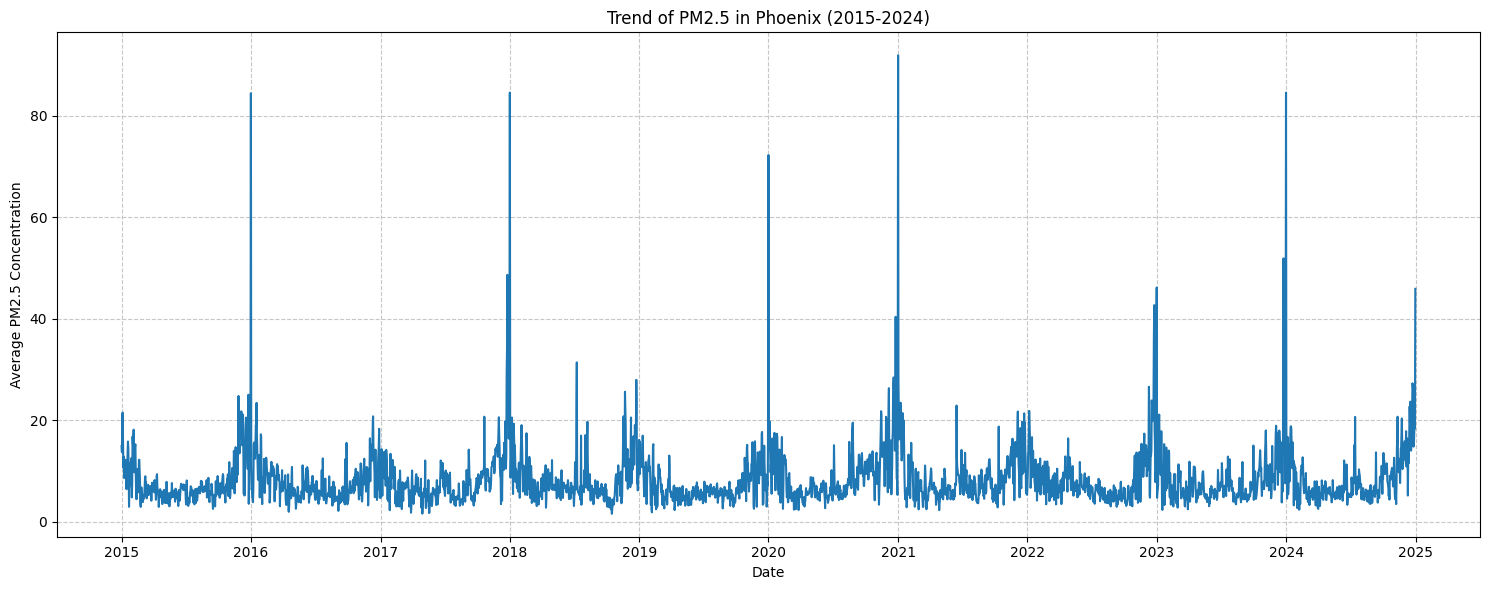

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'date_local' is a datetime object
df['date_local'] = pd.to_datetime(df['date_local'])

# Get unique cities and pollutants
unique_cities = df['city'].unique()
unique_pollutants = df['pollutant'].unique()

# Create a plot for each city-pollutant combination
for city in unique_cities:
    for pollutant in unique_pollutants:
        # Filter data for the current city and pollutant
        subset_df = df[(df['city'] == city) & (df['pollutant'] == pollutant)].sort_values('date_local')

        # Only plot if there is data for the combination
        if not subset_df.empty:
            plt.figure(figsize=(15, 6))
            sns.lineplot(x='date_local', y='avg_concentration', data=subset_df)
            plt.title(f'Trend of {pollutant} in {city} (2015-2024)')
            plt.xlabel('Date')
            plt.ylabel(f'Average {pollutant} Concentration')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()


In [ ]:
# Store your EPA API key securely
# You can either paste it directly here (for private notebooks) or use Colab's Secrets feature
# For demonstration, I'll store it as a variable. Replace 'orangecrane52' with your actual key if different.
epa_api_key = 'tawnycat94'

print("API key stored. Please specify which EPA API you'd like to use and what data you're interested in.")

API key stored. Please specify which EPA API you'd like to use and what data you're interested in.


In [ ]:
import requests
import pandas as pd
import time

EMAIL    = "everett.ypsilantis22@gmail.com"
BASE_URL = "https://aqs.epa.gov/data/api/dailyData/byCounty"

POLLUTANTS = {
    "PM2.5": "88101",
    "O3":    "44201",
    "CO":    "42101",
    "NO2":   "42602",
}

YEARS = range(2015, 2025)

def fetch_city(state_code, county_code, city_name):
    frames = []
    for year in YEARS:
        for pollutant, param_code in POLLUTANTS.items():
            print(f"  Fetching {pollutant} | {year}...")
            r = requests.get(BASE_URL, params={
                "email":  EMAIL,
                "key":    epa_api_key,
                "param":  param_code,
                "bdate":  f"{year}0101",
                "edate":  f"{year}1231",
                "state":  state_code,
                "county": county_code,
            })
            data = r.json()
            if data["Header"][0]["status"] == "Success" and data.get("Data"):
                df = pd.DataFrame(data["Data"])
                df["city"]      = city_name
                df["pollutant"] = pollutant
                frames.append(df)
            else:
                print(f"    No data returned.")
            time.sleep(0.5)
    if frames:
        result = pd.concat(frames, ignore_index=True)
        print(f"{city_name}: {len(result)} records collected.")
        return result
    else:
        print(f"{city_name}: No data collected.")
        return pd.DataFrame()

print("Config ready.")

Config ready.


In [ ]:
df['year'] = df['date_local'].dt.year
avg_concentration_per_year = df.groupby(['year', 'city', 'pollutant'])['avg_concentration'].mean().reset_index()
print(avg_concentration_per_year.head(20))

    year         city pollutant  avg_concentration
0   2015      Chicago        CO           0.277972
1   2015      Chicago       NO2          15.005011
2   2015      Chicago        O3           0.025589
3   2015      Chicago     PM2.5          10.711396
4   2015      Houston        CO           0.280987
5   2015      Houston       NO2           9.497834
6   2015      Houston        O3           0.022693
7   2015      Houston     PM2.5          10.708330
8   2015  Los Angeles        CO           0.354515
9   2015  Los Angeles       NO2          15.624325
10  2015  Los Angeles        O3           0.029781
11  2015  Los Angeles     PM2.5          11.430349
12  2015     New York        CO           0.345547
13  2015     New York        O3           0.022423
14  2015     New York     PM2.5           9.939187
15  2015      Phoenix        CO           0.402871
16  2015      Phoenix       NO2          17.076388
17  2015      Phoenix        O3           0.032236
18  2015      Phoenix     PM2.5

In [ ]:
import pandas as pd

df_census = pd.read_csv('/content/Census Population Data.csv')
display(df_census.head())

,Rank,City,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,1,New York,"8,203,084","8,337,907","8,463,961","8,565,517","8,655,238","8,736,590","8,794,592","8,815,395","8,826,377","8,824,751","8,804,200","8,453,772","8,356,179","8,390,888","8,478,072"
1,2,Los Angeles,"3,793,252","3,809,020","3,830,206","3,852,446","3,870,990","3,892,691","3,908,706","3,918,411","3,916,642","3,910,544","3,898,792","3,830,987","3,832,998","3,847,428","3,878,704"
2,3,Chicago,"2,699,056","2,715,964","2,733,275","2,746,132","2,753,676","2,757,203","2,755,833","2,756,313","2,753,146","2,749,996","2,746,352","2,706,324","2,684,076","2,699,144","2,721,308"
3,4,Houston,"2,097,321","2,121,657","2,155,742","2,192,094","2,233,069","2,276,719","2,298,146","2,303,550","2,303,636","2,303,565","2,304,515","2,291,070","2,314,258","2,346,908","2,390,125"
4,5,Phoenix,"1,446,636","1,457,935","1,477,917","1,495,699","1,515,206","1,534,007","1,553,052","1,564,980","1,576,886","1,595,263","1,608,184","1,625,132","1,644,798","1,656,231","1,673,164"


In [ ]:
import pandas as pd

df_AQ = pd.read_csv('/content/air_quality_master.csv')
display(df_AQ.head())

,city,pollutant,date_local,avg_concentration
0,Chicago,CO,2015-01-01,0.166613
1,Chicago,CO,2015-01-02,0.301167
2,Chicago,CO,2015-01-03,0.460375
3,Chicago,CO,2015-01-04,0.241875
4,Chicago,CO,2015-01-05,0.201375


In [ ]:
df_AQ['date_local'] = pd.to_datetime(df_AQ['date_local'])
df_AQ['year'] = df_AQ['date_local'].dt.year
display(df_AQ.head())

,city,pollutant,date_local,avg_concentration,year
0,Chicago,CO,2015-01-01,0.166613,2015
1,Chicago,CO,2015-01-02,0.301167,2015
2,Chicago,CO,2015-01-03,0.460375,2015
3,Chicago,CO,2015-01-04,0.241875,2015
4,Chicago,CO,2015-01-05,0.201375,2015


### Merging Air Quality Data with Census Population Data

To combine the air quality data with the census population data, we need to perform a merge operation. However, the `df_census` table has years as column headers, while `df_AQ` has a `year` column. First, we'll transform `df_census` into a 'long' format where years are in a single column, and then we'll merge the two dataframes on the `city` and `year` columns.

In [ ]:
# Melt df_census to get years as a column
df_census_melted = df_census.melt(id_vars=['Rank', 'City'], var_name='year', value_name='population')

# Convert 'year' column to integer type to match df_AQ
df_census_melted['year'] = pd.to_numeric(df_census_melted['year'], errors='coerce')

# Clean 'population' column: remove commas and convert to numeric
df_census_melted['population'] = df_census_melted['population'].astype(str).str.replace(',', '', regex=False)
df_census_melted['population'] = pd.to_numeric(df_census_melted['population'], errors='coerce')

# Drop rows where 'year' or 'population' conversion failed
df_census_melted.dropna(subset=['year', 'population'], inplace=True)

# Rename 'City' column to 'city' for consistent merging
df_census_melted.rename(columns={'City': 'city'}, inplace=True)

display(df_census_melted.head(20))

,Rank,city,year,population
0,1,New York,2010,8203084
1,2,Los Angeles,2010,3793252
2,3,Chicago,2010,2699056
3,4,Houston,2010,2097321
4,5,Phoenix,2010,1446636
5,1,New York,2011,8337907
6,2,Los Angeles,2011,3809020
7,3,Chicago,2011,2715964
8,4,Houston,2011,2121657
9,5,Phoenix,2011,1457935


In [ ]:
# Merge df_AQ with the melted df_census_melted
df_merged = pd.merge(df_AQ, df_census_melted[['city', 'year', 'population']], on=['city', 'year'], how='left')

# Display the head of the merged DataFrame and its info to check for nulls
display(df_merged.head(30))
df_merged.info()

,city,pollutant,date_local,avg_concentration,year,population
0,Chicago,CO,2015-01-01,0.166613,2015,2757203
1,Chicago,CO,2015-01-02,0.301167,2015,2757203
2,Chicago,CO,2015-01-03,0.460375,2015,2757203
3,Chicago,CO,2015-01-04,0.241875,2015,2757203
4,Chicago,CO,2015-01-05,0.201375,2015,2757203
5,Chicago,CO,2015-01-06,0.212500,2015,2757203
6,Chicago,CO,2015-01-07,0.191875,2015,2757203
7,Chicago,CO,2015-01-08,0.195729,2015,2757203
8,Chicago,CO,2015-01-09,0.191261,2015,2757203
9,Chicago,CO,2015-01-10,0.203437,2015,2757203


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66237 entries, 0 to 66236
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   city               66237 non-null  object        
 1   pollutant          66237 non-null  object        
 2   date_local         66237 non-null  datetime64[ns]
 3   avg_concentration  66237 non-null  float64       
 4   year               66237 non-null  int32         
 5   population         66237 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(1), object(2)
memory usage: 2.8+ MB


In [ ]:
import pandas as pd

df_Weather = pd.read_csv('/content/Weather.csv')
display(df_Weather.head(1))

,City,Year,Precp_In,Tavg_F,Tmax_F,T_minF
0,Houston,2015,70.05,70.3,79.8,60.7


In [ ]:
# Rename columns in df_Weather for consistent merging
df_Weather.rename(columns={'City': 'city', 'Year': 'year'}, inplace=True)

# Merge df_merged with df_Weather on 'city' and 'year'
df_combined_sets = pd.merge(df_merged, df_Weather, on=['city', 'year'], how='left')

# Display the head of the new combined DataFrame
display(df_combined_sets.head())

,city,pollutant,date_local,avg_concentration,year,population,Precp_In,Tavg_F,Tmax_F,T_minF
0,Chicago,CO,2015-01-01,0.166613,2015,2757203,39.88,50.1,58.9,41.3
1,Chicago,CO,2015-01-02,0.301167,2015,2757203,39.88,50.1,58.9,41.3
2,Chicago,CO,2015-01-03,0.460375,2015,2757203,39.88,50.1,58.9,41.3
3,Chicago,CO,2015-01-04,0.241875,2015,2757203,39.88,50.1,58.9,41.3
4,Chicago,CO,2015-01-05,0.201375,2015,2757203,39.88,50.1,58.9,41.3


In [ ]:
df_final = df_combined_sets.drop(columns=['date_local'])
df_yearly_avg_concentration_with_details = df_final.groupby([
    'year', 'city', 'pollutant', 'population', 'Precp_In', 'Tavg_F', 'Tmax_F', 'T_minF'
])['avg_concentration'].mean().reset_index()

display(df_yearly_avg_concentration_with_details.head(50))

,year,city,pollutant,population,Precp_In,Tavg_F,Tmax_F,T_minF,avg_concentration
0,2015,Chicago,CO,2757203,39.88,50.1,58.9,41.3,0.277972
1,2015,Chicago,NO2,2757203,39.88,50.1,58.9,41.3,15.005011
2,2015,Chicago,O3,2757203,39.88,50.1,58.9,41.3,0.025589
3,2015,Chicago,PM2.5,2757203,39.88,50.1,58.9,41.3,10.711396
4,2015,Houston,CO,2276719,70.05,70.3,79.8,60.7,0.280987
5,2015,Houston,NO2,2276719,70.05,70.3,79.8,60.7,9.497834
6,2015,Houston,O3,2276719,70.05,70.3,79.8,60.7,0.022693
7,2015,Houston,PM2.5,2276719,70.05,70.3,79.8,60.7,10.708330
8,2015,Los Angeles,CO,3892691,7.67,68.3,77.9,58.7,0.354515
9,2015,Los Angeles,NO2,3892691,7.67,68.3,77.9,58.7,15.624325


In [ ]:
df_yearly_avg_concentration_with_details.to_csv('yearly_enviromental_breakdown.csv', index=False)

In [ ]:
import requests
import pandas as pd
import time

token = "jNgRGzhikQFQuLBaOTInkMIqATxYtvuB"

stations = {
    "New York": "GHCND:USW00094728",
    "Los Angeles": "GHCND:USW00023174",
    "Chicago": "GHCND:USW00094846",
    "Houston": "GHCND:USW00012960",
    "Phoenix": "GHCND:USW00023183"
}

all_data = []

for city, station_id in stations.items():
    for year in range(2015, 2025):
        url = "https://www.ncei.noaa.gov/cdo-web/api/v2/data"
        params = {
            "datasetid": "GSOM",
            "stationid": station_id,
            "startdate": f"{year}-01-01",
            "enddate": f"{year}-12-31",
            "datatypeid": "TAVG,PRCP",
            "units": "standard",
            "limit": 1000
        }
        headers = {"token": token}

        # Retry up to 3 times
        for attempt in range(3):
            response = requests.get(url, params=params, headers=headers)
            if response.status_code == 200:
                data = response.json().get("results", [])
                for record in data:
                    record["city"] = city
                all_data.extend(data)
                print(f"Success: {city} {year}")
                break
            else:
                print(f"Attempt {attempt+1} failed for {city} {year} — retrying in 10 seconds...")
                time.sleep(10)

        time.sleep(1)  # 1 second pause between every request

df_weather = pd.DataFrame(all_data)
print(df_weather.head())

Success: New York 2015
Success: New York 2016
Success: New York 2017
Success: New York 2018


In [ ]:
df_weather.head(25)

,date,datatype,station,attributes,value,city
0,2015-01-01T00:00:00,PRCP,GHCND:USW00094728,",,,W",5.22,New York
1,2015-01-01T00:00:00,TAVG,GHCND:USW00094728,",W",29.90,New York
2,2015-02-01T00:00:00,PRCP,GHCND:USW00094728,",,,W",2.04,New York
3,2015-02-01T00:00:00,TAVG,GHCND:USW00094728,",W",24.10,New York
4,2015-03-01T00:00:00,PRCP,GHCND:USW00094728,",,,W",4.73,New York
5,2015-03-01T00:00:00,TAVG,GHCND:USW00094728,",W",38.10,New York
6,2015-04-01T00:00:00,PRCP,GHCND:USW00094728,",,,W",2.08,New York
7,2015-04-01T00:00:00,TAVG,GHCND:USW00094728,",W",54.30,New York
8,2015-05-01T00:00:00,PRCP,GHCND:USW00094728,",,,W",1.86,New York
9,2015-05-01T00:00:00,TAVG,GHCND:USW00094728,",W",68.50,New York


In [ ]:
df['month'] = df['date_local'].dt.month
display(df.head())

,city,pollutant,date_local,avg_concentration,year,month
0,Chicago,CO,2015-01-01,0.166613,2015,1
1,Chicago,CO,2015-01-02,0.301167,2015,1
2,Chicago,CO,2015-01-03,0.460375,2015,1
3,Chicago,CO,2015-01-04,0.241875,2015,1
4,Chicago,CO,2015-01-05,0.201375,2015,1


In [ ]:
df_weather['date'] = pd.to_datetime(df_weather['date'])
df_weather['month'] = df_weather['date'].dt.month
display(df_weather.head())

,date,datatype,station,attributes,value,city,month
0,2015-01-01,PRCP,GHCND:USW00094728,",,,W",5.22,New York,1
1,2015-01-01,TAVG,GHCND:USW00094728,",W",29.90,New York,1
2,2015-02-01,PRCP,GHCND:USW00094728,",,,W",2.04,New York,2
3,2015-02-01,TAVG,GHCND:USW00094728,",W",24.10,New York,2
4,2015-03-01,PRCP,GHCND:USW00094728,",,,W",4.73,New York,3


In [ ]:
df_AQ['year'] = df_AQ['date_local'].dt.year
df_AQ['month'] = df_AQ['date_local'].dt.month
# Step 1: Aggregate air quality to monthly level
df_pollutant_monthly = df_AQ.groupby(['city', 'pollutant', 'year', 'month']).agg(
    avg_concentration=('avg_concentration', 'mean')
).reset_index()

# Extract year from df_weather's 'date' column
df_weather['year'] = df_weather['date'].dt.year

# Step 2: Pivot weather so PRCP and TAVG become their own columns
df_weather_pivot = df_weather.pivot_table(
    index=['city', 'year', 'month'],
    columns='datatype',
    values='value',
    aggfunc='first'
).reset_index()

df_weather_pivot = df_weather_pivot.rename(columns={'PRCP': 'precip', 'TAVG': 'tavg'})
df_weather_pivot = df_weather_pivot[['city', 'year', 'month', 'precip', 'tavg']]

# Step 3: Merge
df_final = df_pollutant_monthly.merge(
    df_weather_pivot,
    on=['city', 'year', 'month'],
    how='inner'
)

print(df_final.head())

       city pollutant  year  month  avg_concentration  precip  tavg
0   Chicago        CO  2015      1           0.239951    1.41  22.4
1   Chicago        CO  2015      2           0.347014    1.46  14.7
2   Chicago        CO  2015      3           0.259718    1.10  35.4
3   Chicago        CO  2015      4           0.271056    2.87  49.4
4   Chicago        CO  2015      5           0.269392    4.67  60.3
5   Chicago        CO  2015      6           0.243698    7.12  67.3
6   Chicago        CO  2015      7           0.375038    2.85  72.3
7   Chicago        CO  2015      8           0.529688    2.16  71.7
8   Chicago        CO  2015      9           0.192319    4.64  69.0
9   Chicago        CO  2015     10           0.150814    2.24  54.7
10  Chicago        CO  2015     11           0.238740    4.49  44.6
11  Chicago        CO  2015     12           0.228762    4.87  39.0
12  Chicago        CO  2016      1           0.244532    0.85  24.8
13  Chicago        CO  2016      2           0.2

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2274 entries, 0 to 2273
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   city               2274 non-null   object 
 1   pollutant          2274 non-null   object 
 2   year               2274 non-null   int32  
 3   month              2274 non-null   int32  
 4   avg_concentration  2274 non-null   float64
 5   precip             2274 non-null   float64
 6   tavg               2274 non-null   float64
dtypes: float64(3), int32(2), object(2)
memory usage: 106.7+ KB


In [ ]:
display(df_final['city'].unique())

array(['Chicago', 'Houston', 'Los Angeles', 'New York', 'Phoenix'],
      dtype=object)

In [ ]:
display(df_final['pollutant'].unique())

array(['CO', 'NO2', 'O3', 'PM2.5'], dtype=object)

In [ ]:
display(df_final['month'].unique())

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

In [ ]:
display(df_final['year'].unique())

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
      dtype=int32)

In [ ]:
df_final = df_final.rename(columns={'precip': 'precip_in', 'tavg': 'tavg_f'})
display(df_final.head())

,city,pollutant,year,month,avg_concentration,precip_in,tavg_f
0,Chicago,CO,2015,1,0.239951,1.41,22.4
1,Chicago,CO,2015,2,0.347014,1.46,14.7
2,Chicago,CO,2015,3,0.259718,1.10,35.4
3,Chicago,CO,2015,4,0.271056,2.87,49.4
4,Chicago,CO,2015,5,0.269392,4.67,60.3


In [ ]:
display(df_census_melted.head(20))

,Rank,city,year,population
0,1,New York,2010,8203084
1,2,Los Angeles,2010,3793252
2,3,Chicago,2010,2699056
3,4,Houston,2010,2097321
4,5,Phoenix,2010,1446636
5,1,New York,2011,8337907
6,2,Los Angeles,2011,3809020
7,3,Chicago,2011,2715964
8,4,Houston,2011,2121657
9,5,Phoenix,2011,1457935


In [ ]:
df_final = pd.merge(df_final, df_census_melted[['city', 'year', 'population']], on=['city', 'year'], how='left')
display(df_final.head(20))

,city,pollutant,year,month,avg_concentration,precip_in,tavg_f,population_x,population_y
0,Chicago,CO,2015,1,0.239951,1.41,22.4,2757203,2757203
1,Chicago,CO,2015,2,0.347014,1.46,14.7,2757203,2757203
2,Chicago,CO,2015,3,0.259718,1.10,35.4,2757203,2757203
3,Chicago,CO,2015,4,0.271056,2.87,49.4,2757203,2757203
4,Chicago,CO,2015,5,0.269392,4.67,60.3,2757203,2757203
5,Chicago,CO,2015,6,0.243698,7.12,67.3,2757203,2757203
6,Chicago,CO,2015,7,0.375038,2.85,72.3,2757203,2757203
7,Chicago,CO,2015,8,0.529688,2.16,71.7,2757203,2757203
8,Chicago,CO,2015,9,0.192319,4.64,69.0,2757203,2757203
9,Chicago,CO,2015,10,0.150814,2.24,54.7,2757203,2757203


In [ ]:
display(df_final.head(20))


NameError: name 'df_final' is not defined

In [ ]:
df_final.to_csv('city_pollutants_climate_population.csv', index=False)